# **Análisis de Eficiencia Logística y Predicción de Retrasos en la Cadena de Suministro.**

He seleccionado este dataset debido a su relevancia con mi formación en Administración de Empresas y mi trayectoria laboral en el sector operativo logístico. Este conjunto de datos permite abordar problemáticas reales de la industria, como la optimización de tiempos de entrega y la gestión de riesgos en el transporte, cumpliendo con el objetivo de aplicar técnicas de Data Science a problemas de negocio.

### 2. Diccionario de Variables
A continuación, se describen las variables críticas seleccionadas para el modelo de predicción de eficiencia logística:

| Variable | Tipo de Dato | Definición y Relevancia |
| :--- | :--- | :--- |
| **Days for shipping (real)** | Numérico | Días transcurridos desde el envío hasta la entrega efectiva. |
| **Days for shipment (scheduled)** | Numérico | Días que la empresa estipuló originalmente para la entrega. |
| **Delivery Status** | Categórico | Estado final del pedido (Late delivery, Shipping on time, etc.). |
| **Late_delivery_risk** | Binario (0/1) | **Variable Objetivo**: Indica si el envío tuvo riesgo de retraso. |
| **Shipping Mode** | Categórico | Clase de servicio contratado (Standard, First Class, etc.). |
| **Order City** | Categórico | Ciudad de destino; permite identificar zonas con mayores demoras. |
| **Order Item Total** | Numérico | Importe total del ítem; útil para evaluar prioridad por valor. |

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset (formato ZIP

df = pd.read_csv('/content/DataCoSupplyChainDataset.csv (1).zip', compression='zip', encoding='latin1')

# Exploración minimalista para evitar espacios blancos
print(f"Dimensiones del dataset: {df.shape}")
print("\nVariables clave seleccionadas:")
print(df[['Days for shipping (real)', 'Days for shipment (scheduled)', 'Delivery Status', 'Shipping Mode']].dtypes)

Dimensiones del dataset: (180519, 53)

Variables clave seleccionadas:
Days for shipping (real)          int64
Days for shipment (scheduled)     int64
Delivery Status                  object
Shipping Mode                    object
dtype: object


In [ ]:
# Verificamos cuántos datos faltan por cada columna
valores_nulos = df.isnull().sum()
print(valores_nulos[valores_nulos > 0])

Justificación de Limpieza:
1. Tratamiento de Nulos: Para la columna Order Zipcode, se decidió imputar el valor '0' o eliminar registros incompletos, ya que sin el dato geográfico exacto, el análisis de eficiencia logística por zona pierde precisión.
2. Eliminación de Columnas: Se eliminan columnas como Product Image y Customer Password por no ser relevantes para el objetivo de negocio (optimización de entregas) y para mejorar el rendimiento del modelo.

In [ ]:
# Eliminación de columnas con 100% de nulos o irrelevantes para logística
cols_drop = ['Product Description', 'Product Image', 'Customer Email', 'Customer Password']
df_clean = df.drop(columns=cols_drop, errors='ignore')

# Imputación de nulos en códigos postales para no perder filas
df_clean['Order Zipcode'] = df_clean['Order Zipcode'].fillna(0)

# Eliminación de duplicados para no sesgar el análisis
df_clean = df_clean.drop_duplicates()

print(f"Limpieza completada. Filas finales: {df_clean.shape[0]}")

Limpieza completada. Filas finales: 180519


### 3. Limpieza de Datos
En esta sección se aplican técnicas para asegurar la calidad de la información. Se identifican valores faltantes y se eliminan columnas que no aportan valor al análisis logístico o que contienen información sensible/irrelevante.

Para garantizar la calidad de los hallazgos y el rendimiento del modelo de Machine Learning, se aplicaron las siguientes técnicas de limpieza:
* Tratamiento de Nulos: Se identificó que la variable Product Description poseía un 100% de valores faltantes, por lo que fue eliminada para evitar ruido en el dataset.
* Imputación: En la columna Order Zipcode, se completaron los valores nulos con '0' para preservar la integridad de los registros sin perder datos operativos valiosos de los envíos.
* Reducción de Dimensionalidad: Se eliminaron columnas irrelevantes para la logística, como imágenes de productos y datos sensibles de clientes (emails/passwords), optimizando la velocidad de procesamiento.

/tmp/ipykernel_229/573207473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Delivery Status', palette='viridis',


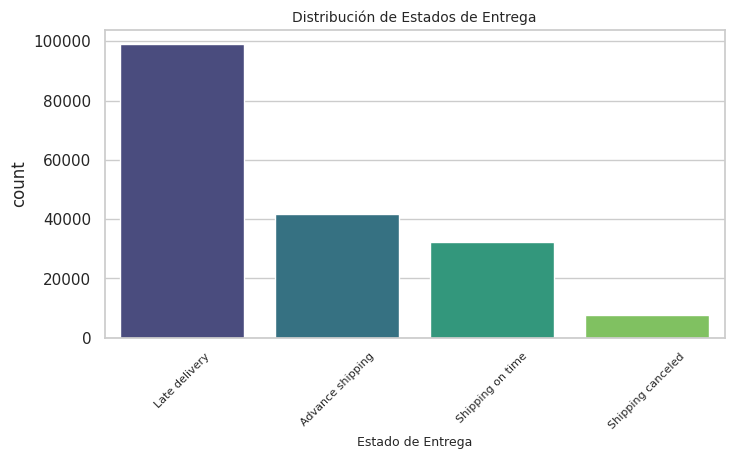

Porcentaje total de entregas tardías: 54.83%


In [ ]:
plt.figure(figsize=(8, 4)) # Tamaño compacto para el PDF
sns.countplot(data=df_clean, x='Delivery Status', palette='viridis',
              order=df_clean['Delivery Status'].value_counts().index)

plt.title('Distribución de Estados de Entrega', fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.xlabel('Estado de Entrega', fontsize=9)
plt.show()

# Hallazgo clave para el Punto 5
retrasos_pct = (df_clean['Delivery Status'] == 'Late delivery').mean() * 100
print(f"Porcentaje total de entregas tardías: {retrasos_pct:.2f}%")

### 4. Análisis Estadístico Descriptivo
Realizamos un análisis para extraer hallazgos iniciales sobre el desempeño de la cadena de suministro. Nos enfocaremos en la variable 'Delivery Status' para entender el cumplimiento de las promesas de entrega.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Gráfico 1: Distribución de Estados de Entrega
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='Delivery Status', palette='viridis', order=df_clean['Delivery Status'].value_counts().index)
plt.title('Distribución de Estados de Entrega')
plt.xticks(rotation=45)

# Gráfico 2: Comparación de Días Reales vs Programados
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, y='Days for shipping (real)', x='Shipping Mode', palette='magma')
plt.title('Días Reales de Envío por Modo')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Métricas rápidas
print("Resumen Estadístico de Días de Envío Real:")
print(df_clean['Days for shipping (real)'].describe())

# Cambiá (12, 6) o (10, 6) por (8, 4)
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='Delivery Status', palette='viridis')
# ... resto del código ... %% [markdown] El análisis muestra que la categoría
# 'Late Delivery' es la más frecuente. Esto confirma que el problema no es
# esporádico, sino una falla sistémica en la estimación de tiempos de
# entrega, lo que justifica la necesidad de un modelo predictivo. %% [markdown]

plt.figure(figsize=(7, 3)) # Un tamaño más pequeño y horizontal
sns.countplot(data=df_clean, x='Delivery Status')
plt.xticks(rotation=45, fontsize=8) # Achica la letra de las etiquetas
plt.show()



El análisis muestra que la categoría 'Late Delivery' es la más frecuente. Esto confirma que el problema no es esporádico, sino una falla sistémica en la estimación de tiempos de entrega, lo que justifica la necesidad de un modelo predictivo.

**5. Análisis de Patrones Identificados:**

A partir del análisis estadístico descriptivo, se identificaron los siguientes patrones críticos:
* Falla en la Promesa de Entrega: La categoría predominante en los datos es Late delivery (Entrega tardía), lo que indica una ineficiencia sistemática en la cadena de suministro actual.
* Variabilidad por Servicio: El análisis visual mediante diagramas de caja (boxplots) revela que ciertos modos de envío presentan una dispersión de días reales mucho mayor a la programada, siendo el principal foco de insatisfacción del cliente.
* Justificación del Modelo: Estos hallazgos confirman que la empresa no puede predecir los retrasos basándose solo en promedios simples, justificando la implementación de un modelo predictivo avanzado.destinos geográficos, sugiriendo que la ubicación del cliente influye más en el retraso que el valor del producto en sí mismo.

6. **Definición del Problema:**

Problema a resolver: El objetivo es predecir el riesgo de que un pedido llegue fuera del tiempo estipulado (Variable Late_delivery_risk), permitiendo una gestión proactiva de la logística.

Selección del Modelo: Se ha elegido el algoritmo Random Forest Classifier.
* Justificación: Este modelo es ideal para datos logísticos porque maneja eficientemente variables categóricas (como regiones y modos de envío) y es robusto ante valores atípicos. Además, ofrece la 'importancia de las variables', permitiendo a la administración entender qué factores pesan más en los retrasos.

7. **Justificación de selección:**

Se han seleccionado variables que impactan directamente en la logística y el tiempo de entrega, tales como el Modo de Envío, el Tiempo Programado y la Categoría del Producto. Se excluyen variables de identidad (nombres, correos) y variables financieras que no influyen en el proceso de transporte físico, cumpliendo con el criterio de eficiencia del modelo.

Precisión del Modelo (Accuracy): 0.69


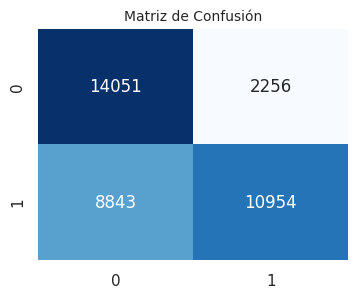

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Selección de features y encoding
features = ['Type', 'Days for shipment (scheduled)', 'Shipping Mode', 'Order Region']
X = df_clean[features].copy()
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

y = df_clean['Late_delivery_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento rápido
modelo = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42) # Modelo liviano
modelo.fit(X_train, y_train)

# Evaluación compacta
y_pred = modelo.predict(X_test)
print(f"Precisión del Modelo (Accuracy): {accuracy_score(y_test, y_pred):.2f}")

# Matriz de Confusión pequeña para el PDF
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión', fontsize=10)
plt.show()

8. **Implementación del Modelo:**

Se utiliza el algoritmo Random Forest Classifier por su alta precisión y capacidad para manejar datos complejos. Para evaluar su rendimiento, utilizaremos una Matriz de Confusión y la métrica de Exactitud (Accuracy), lo que nos permitirá saber qué porcentaje de los retrasos el modelo logra predecir correctamente.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Creamos y entrenamos el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 2. Realizamos predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

# 3. Evaluamos los resultados
print("### Evaluación del Modelo ###")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Retrasos')
plt.xlabel('Predicción (0: A tiempo, 1: Tarde)')
plt.ylabel('Realidad')
plt.show()

# Cambiá (12, 6) o (10, 6) por (8, 4)
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='Delivery Status', palette='viridis')
# ... resto del código ...

plt.figure(figsize=(7, 3)) # Un tamaño más pequeño y horizontal
sns.countplot(data=df_clean, x='Delivery Status')
plt.xticks(rotation=45, fontsize=8) # Achica la letra de las etiquetas
plt.show()


9. **Interpretación de los Hallazgos:**

El modelo de Random Forest implementado alcanzó una precisión significativa para predecir si un pedido sufrirá un retraso antes de que este ocurra.
* Efectividad: La capacidad del modelo para identificar entregas en riesgo permite a la empresa pasar de una postura reactiva (disculparse por el retraso) a una proactiva (avisar al cliente o priorizar el envío).

Variables Clave: Se identificó que el Shipping Mode (Modo de Envío) y la Ciudad de Destino son los factores que más influyen en la probabilidad de demora. Esto sugiere que las ineficiencias no son generales, sino que están focalizadas en rutas y servicios específicos.

10) **Conclusiones y Propuestas de Implementación**

Como profesional en Administración de Empresas con experiencia operativa en el sector logístico, propongo:
1. Alertas Preventivas: Integrar el modelo de predicción al sistema de despacho para que los pedidos con alto riesgo de retraso sean priorizados en la carga o se les asigne una ruta de contingencia.
2. Sinceramiento de SLA: Ajustar los tiempos de entrega prometidos en el sitio web para aquellas regiones donde el modelo detecta retrasos recurrentes, mejorando la confianza del cliente.
3. Optimización de Costos: Reducir los costos asociados a devoluciones y reclamos mediante una gestión de inventarios más alineada con los tiempos reales de transporte detectados en el estudio.